In [2]:
from google.colab import drive
import pandas as pd
# Mount Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [37]:
from xgboost import XGBRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

In [16]:
path = '/content/drive/MyDrive/Colab Notebooks/project xe cũ/du_lieu_xe_cu_toan_dien.csv'
df = pd.read_csv(path)

In [17]:
df.head()

,Hãng_Mẫu,Năm_SX,Giá_Triệu,Địa_Điểm,Chuỗi_Gốc,Số_KM
0,Mercedes Benz EQS,2022.0,3430,Hà Nội,Ban xe oto cu Mercedes Benz EQS 2022 580 4Mati...,11000.0
1,McLaren 720S,2018.0,12500,Hà Nội,Ban xe oto cu McLaren 720S 2018 4.0 V8 gia 12 ...,18000.0
2,Mitsubishi Pajero Sport,2019.0,615,Hà Nội,Ban xe oto cu Mitsubishi Pajero Sport 2019 2.4...,7000.0
3,Honda CRV,2019.0,680,Hà Nội,Ban xe oto cu Honda CRV 2019 L gia 680 Triệu -...,10000.0
4,Audi A5,2017.0,959,TP HCM,Ban xe oto cu Audi A5 2017 Sportback 2.0 gia 9...,83000.0


In [18]:
def extract_brand(hang_mau):
    hang_mau = str(hang_mau).strip().upper()
    # Xử lý các hãng có 2 chữ cái hoặc dễ bị dính liền
    if hang_mau.startswith("MERCEDES"): return "MERCEDES-BENZ"
    if hang_mau.startswith("ROLL"): return "ROLLS ROYCE"
    if hang_mau.startswith("LANDROVER") or hang_mau.startswith("LAND ROVER"): return "LAND ROVER"
    if hang_mau.startswith("VINFAST"): return "VINFAST"

    # Với các hãng thường (Audi, Toyota, Mazda...), chỉ cần lấy chữ đầu tiên
    return hang_mau.split()[0]

df['Hãng_Xe'] = df['Hãng_Mẫu'].apply(extract_brand)

In [29]:
#count car brand
#df['Hãng_Xe'].value_counts()
#df.head()
# Xóa các dòng thiếu giá trị hoặc năm sản xuất
df = df.dropna(subset=['Giá_Triệu', 'Năm_SX']).copy()

# --- CODE LỌC OUTLIER MỚI THÊM ---
# Chỉ lấy xe có giá từ 50 Triệu đến dưới 10.000 Triệu (10 Tỷ)
df = df[(df['Giá_Triệu'] >= 50) & (df['Giá_Triệu'] <= 10000)]

In [53]:
def classify_brand(hang):
    hang = hang.upper()
    # Nhóm 3: Xe hạng sang
    luxury = ['PORSCHE', 'MERCEDES-BENZ', 'BMW', 'AUDI', 'LEXUS', 'LAND ROVER','VOLVO']

    # Nhóm 2: Xe Nhật/Mỹ giữ giá tốt
    standard_high = ['TOYOTA', 'HONDA', 'FORD', 'MITSUBISHI']

    # Nhóm 1: Xe Hàn, Xe Việt, Xe Âu phổ thông
    standard_normal = ['HYUNDAI', 'KIA', 'MAZDA', 'CHEVROLET', 'PEUGEOT', 'VINFAST']

    if hang in luxury: return 3
    if hang in standard_high: return 2
    if hang in standard_normal: return 1
    return 0 # Nhóm 0: Các hãng còn lại (MG, Suzuki...)

df['Brand_Tier'] = df['Hãng_Xe'].apply(classify_brand)

# 4. TÍNH TUỔI XE
df['Tuổi_Xe'] = 2026 - df['Năm_SX']

# --- HIỂN THỊ KẾT QUẢ ĐỂ KIỂM TRA ---
print(df[['Hãng_Mẫu', 'Hãng_Xe', 'Brand_Tier', 'Tuổi_Xe', 'Giá_Triệu']].head(15))

                   Hãng_Mẫu        Hãng_Xe  Brand_Tier  Tuổi_Xe  Giá_Triệu
0         Mercedes Benz EQS  MERCEDES-BENZ           3      4.0       3430
2   Mitsubishi Pajero Sport     MITSUBISHI           2      7.0        615
3                 Honda CRV          HONDA           2      7.0        680
4                   Audi A5           AUDI           3      9.0        959
5     Mercedes Benz C class  MERCEDES-BENZ           3      7.0        969
6              BMW 7 Series            BMW           3     11.0       1199
7            Hyundai Accent        HYUNDAI           1      1.0        455
8             VinFast Fadil        VINFAST           1      5.0        285
9     Mercedes Benz E class  MERCEDES-BENZ           3      5.0       1278
10              VinFast VF5        VINFAST           1      0.0        455
11    LandRover Range Rover     LAND ROVER           3      6.0       7900
12         Porsche Panamera        PORSCHE           3      5.0       5150
13    Mercedes Benz G cla

In [31]:
# 2. XÂY DỰNG MÔ HÌNH RANDOM FOREST
df_model = pd.get_dummies(df, columns=['Hãng_Xe'], drop_first=True)

# Lấy các cột làm đặc trưng (Features)
features = ['Tuổi_Xe', 'Brand_Tier','Số_KM'] + [c for c in df_model.columns if c.startswith('Hãng_Xe_')]

X = df_model[features]
y = df_model['Giá_Triệu']

# Chia tập dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo và Huấn luyện mô hình
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Dự đoán và Đánh giá
y_pred = model.predict(X_test)
print(f"✅ Sai số trung bình (MAE): {mean_absolute_error(y_test, y_pred):.2f} Triệu VNĐ")
print(f"✅ Độ chính xác (R2 Score): {r2_score(y_test, y_pred):.2f}")

✅ Sai số trung bình (MAE): 461.27 Triệu VNĐ
✅ Độ chính xác (R2 Score): 0.57


In [46]:
df_clean = df[(df['Giá_Triệu'] >= 50) & (df['Giá_Triệu'] <= 3000)].copy()
df_model = pd.get_dummies(df_clean, columns=['Hãng_Xe'], drop_first=True)
features = ['Tuổi_Xe', 'Brand_Tier'] + [c for c in df_model.columns if c.startswith('Hãng_Xe_')]

X = df_model[features]
y = df_model['Giá_Triệu']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



model_xgb = XGBRegressor(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

print("--- ĐÁNH GIÁ MÔ HÌNH XGBOOST ---")
print(f"✅ MAE: {mean_absolute_error(y_test, y_pred_xgb):.2f} Triệu VNĐ")
print(f"✅ R2 Score: {r2_score(y_test, y_pred_xgb):.2f}")

--- ĐÁNH GIÁ MÔ HÌNH XGBOOST ---
✅ MAE: 243.59 Triệu VNĐ
✅ R2 Score: 0.67


In [48]:
df_test_info = df_clean.loc[X_test.index].copy()
df_test_info['Giá_Dự_Đoán_XGB'] = y_pred_xgb
df_test_info['Dòng_Trong_File'] = X_test.index + 2 # +2 để map chuẩn với file Excel/CSV

# ==========================================
# 4. VẼ BIỂU ĐỒ 1: TỔNG QUAN ZOOM < 5 TỶ
# ==========================================
df_duoi_5_ty = df_test_info[(df_test_info['Giá_Triệu'] <= 5000) & (df_test_info['Giá_Dự_Đoán_XGB'] <= 5000)]
fig1 = px.scatter(
    df_duoi_5_ty,
    x='Giá_Triệu',
    y='Giá_Dự_Đoán_XGB',
    hover_data=['Dòng_Trong_File', 'Hãng_Mẫu', 'Năm_SX'],
    title="Biểu đồ Tương tác XGBoost: Dự đoán vs Thực tế (< 5 Tỷ)",
    labels={'Giá_Triệu': 'Giá Niêm Yết (Triệu VNĐ)', 'Giá_Dự_Đoán_XGB': 'Giá XGBoost Dự Đoán'},
    color_discrete_sequence=['#1f77b4'],
    opacity=0.6
)
# Vẽ đường chuẩn màu đỏ
fig1.add_shape(type="line", x0=0, y0=0, x1=5000, y1=5000, line=dict(color="red", dash="dash"))
fig1.show()

# ==========================================
# 5. VẼ BIỂU ĐỒ 2: PHÂN KHÚC BÌNH DÂN < 1 TỶ
# ==========================================


In [55]:
df_duoi_1_ty = df_test_info[(df_test_info['Giá_Triệu'] <= 1500) & (df_test_info['Giá_Dự_Đoán_XGB'] <= 1500)]
fig2 = px.scatter(
    df_duoi_1_ty,
    x='Giá_Triệu',
    y='Giá_Dự_Đoán_XGB',
    hover_data=['Dòng_Trong_File', 'Hãng_Mẫu', 'Năm_SX'],
    color='Brand_Tier', # Đổi màu theo hạng phân khúc xe
    title="XGBoost: Phân Khúc Xe Bình Dân (< 1 Tỷ)",
    labels={'Giá_Triệu': 'Giá Niêm Yết (Triệu VNĐ)', 'Giá_Dự_Đoán_XGB': 'Giá XGBoost Dự Đoán'},
    opacity=0.7
)
fig2.add_shape(type="line", x0=0, y0=0, x1=1500, y1=1500, line=dict(color="red", dash="dash"))
fig2.show()

In [38]:

df_test_info = df.loc[X_test.index].copy() # Lấy lại Hãng_Mẫu, Năm_SX từ file gốc
df_test_info['Giá_Dự_Đoán'] = y_pred # Thêm cột mô hình dự đoán
df_test_info['Dòng_Trong_File'] = X_test.index + 2 # +2 vì index bắt đầu từ 0 và file CSV có 1 dòng tiêu đề

# 2. VẼ BIỂU ĐỒ 1: TẤT CẢ CÁC XE
df_duoi_5_ty = df_test_info[(df_test_info['Giá_Triệu'] <= 5000) & (df_test_info['Giá_Dự_Đoán'] <= 5000)]

fig1 = px.scatter(
    df_duoi_5_ty,
    x='Giá_Triệu',
    y='Giá_Dự_Đoán',
    hover_data=['Dòng_Trong_File', 'Hãng_Mẫu', 'Năm_SX'], # CÁC THÔNG TIN SẼ HIỆN RA KHI CHỈ CHUỘT VÀO
    title="Biểu đồ Tương tác: Dự đoán vs Thực tế (Phân khúc < 5 Tỷ)",
    labels={'Giá_Triệu': 'Giá Niêm Yết (Triệu VNĐ)', 'Giá_Dự_Đoán': 'Giá Mô Hình Tính (Triệu VNĐ)'},
    color_discrete_sequence=['#1f77b4'],
    opacity=0.6
)
# Vẽ đường chéo đỏ chuẩn
fig1.add_shape(type="line", x0=0, y0=0, x1=5000, y1=5000, line=dict(color="red", dash="dash"))
fig1.show()

In [36]:
import plotly.express as px

# Tạo df_test_info từ dữ liệu thực tế và dự đoán
# Lấy các hàng từ df tương ứng với index của y_test
df_test_info = df.loc[y_test.index].copy()
# Thêm cột dự đoán vào DataFrame này
df_test_info['Giá_Dự_Đoán'] = y_pred

#VẼ BIỂU ĐỒ 2: CHỈ DÀNH CHO XE BÌNH DÂN (DƯỚI 1 TỶ)
# Lọc ra nhóm xe < 1000 triệu
df_duoi_1_ty = df_test_info[(df_test_info['Giá_Triệu'] <= 1000) & (df_test_info['Giá_Dự_Đoán'] <= 1000)]

fig2 = px.scatter(
    df_duoi_1_ty,
    x='Giá_Triệu',
    y='Giá_Dự_Đoán',
    hover_data=['Hãng_Mẫu', 'Năm_SX'], # Changed 'Dòng_Trong_File' to 'Hãng_Mẫu'
    title="Biểu đồ Phân Khúc Bình Dân (Dưới 1 Tỷ VNĐ)",
    labels={'Giá_Triệu': 'Giá Niêm Yết (Triệu VNĐ)', 'Giá_Dự_Đoán': 'Giá Mô Hình Tính (Triệu VNĐ)'},
    color='Brand_Tier', # Đổi màu chấm theo hạng xe cho đẹp
    opacity=0.7
)
fig2.add_shape(type="line", x0=0, y0=0, x1=1000, y1=1000, line=dict(color="red", dash="dash"))
fig2.show()

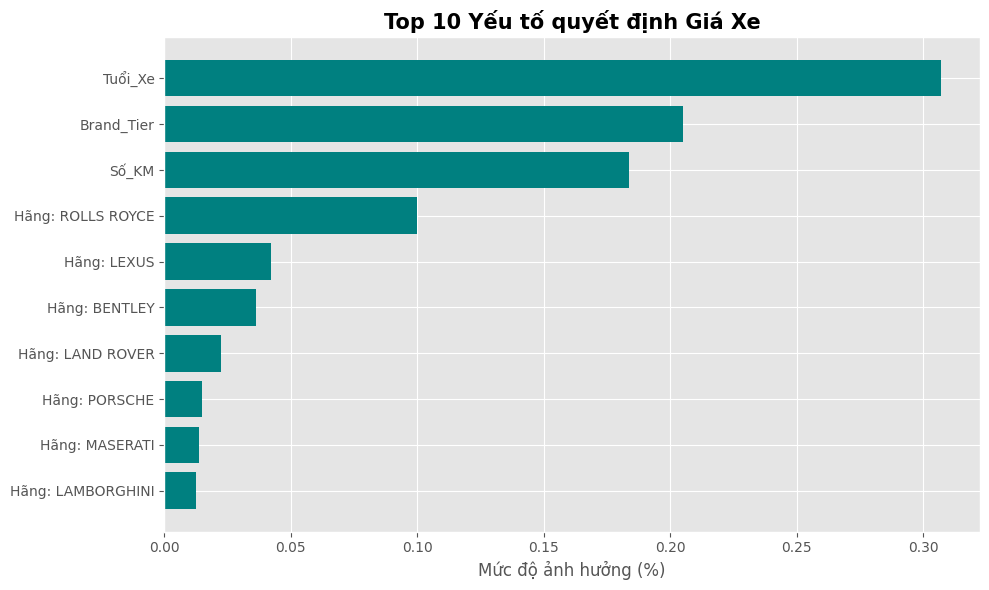

In [26]:
# Biểu đồ 2: Đặc trưng nào quyết định giá xe? (Feature Importance)
importances = model.feature_importances_
indices = np.argsort(importances)[-10:] # Lấy Top 10 biến ảnh hưởng nhất
top_features = [X.columns[i].replace('Hãng_Xe_', 'Hãng: ') for i in indices]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), top_features)
plt.title('Top 10 Yếu tố quyết định Giá Xe', fontsize=15, fontweight='bold')
plt.xlabel('Mức độ ảnh hưởng (%)', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

/tmp/ipykernel_6471/1809441474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Brand_Tier', y='Giá_Triệu', data=df, palette='Set2')


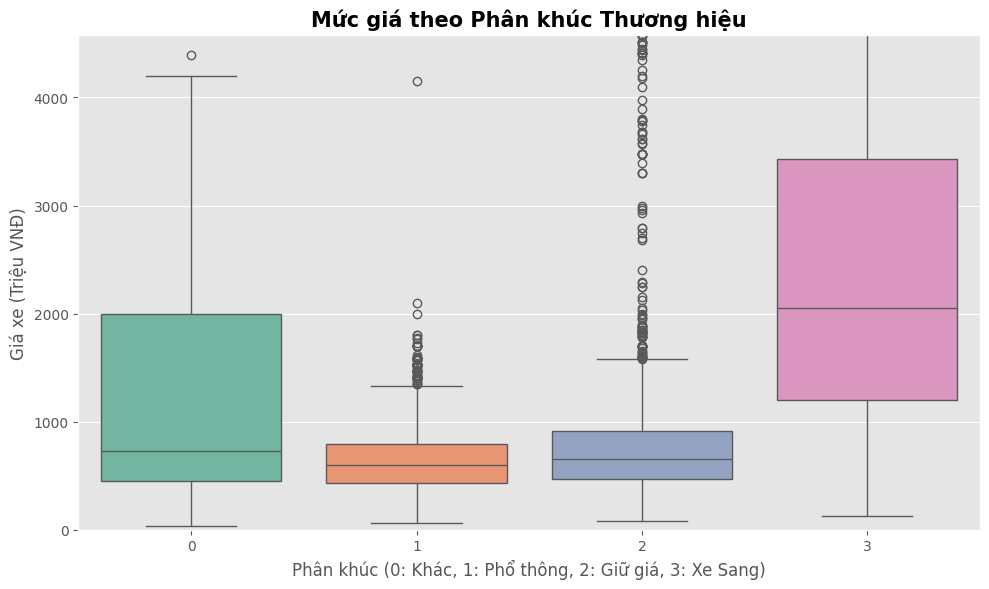

In [27]:
# Biểu đồ 3: Phân bổ giá theo phân khúc (Boxplot với Seaborn + Matplotlib)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Brand_Tier', y='Giá_Triệu', data=df, palette='Set2')
plt.title('Mức giá theo Phân khúc Thương hiệu', fontsize=15, fontweight='bold')
plt.xlabel('Phân khúc (0: Khác, 1: Phổ thông, 2: Giữ giá, 3: Xe Sang)', fontsize=12)
plt.ylabel('Giá xe (Triệu VNĐ)', fontsize=12)
plt.ylim(0, df['Giá_Triệu'].quantile(0.95)) # Cắt bỏ vài chiếc quá siêu xe để biểu đồ dễ nhìn
plt.tight_layout()
plt.savefig('price_by_tier.png')
plt.show()